# E007 — Image augmentation ablation

E004 (PCA+logreg) achieved EER 4.49 ± 4.26% but fold 2 reached 9.17%.
The high variance suggests the model over-adapts to session-specific
appearance (lighting, background, angle in session 03 differs from 01/02).

**Augmentation strategy:** generate additional training samples by transforming
the original images. Val fold always uses original images — we're testing
generalization, not augmented test-time performance.

**Methodological guard:**
- Augment ONLY train fold, never val
- PCA is re-fit on augmented train (so the subspace reflects augmented distribution)
- One axis per config — flip, brightness, and noise tested independently first
- Same seed everywhere for fair comparison

Tested configurations:
1. Baseline (E004 exactly)
2. + Horizontal flip
3. + Brightness jitter [0.7, 1.3]
4. + Gaussian noise σ=15
5. + All combined

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm as scipy_norm
import pandas as pd

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

COLORS = {
    "target":    "#E74C3C",
    "nontarget": "#2E86AB",
    "green":     "#27AE60",
    "purple":    "#8E44AD",
    "gray":      "#95A5A6",
    "orange":    "#E67E22",
}
CONFIG_COLORS = {
    "Baseline":   "#95A5A6",
    "+Flip":      "#2E86AB",
    "+Brightness":"#E67E22",
    "+Noise":     "#8E44AD",
    "+All":       "#E74C3C",
}
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA = Path("../data").resolve()
manifest = load_manifest(DATA)
y_all = manifest["label"].to_numpy()
SEED = 67
print(f"{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target")

222 samples — 30 target, 192 non-target


## 1. Augmentation functions

Each function takes a flat pixel vector `(6400,)` and returns one augmented copy.
They operate in pixel space before PCA — so PCA is trained on the augmented distribution.

In [2]:
def find_png(stem: str, data_dir: Path) -> Path:
    for sf in ["target_train", "target_dev", "non_target_train", "non_target_dev"]:
        p = data_dir / sf / (stem + ".png")
        if p.exists():
            return p
    raise FileNotFoundError(stem)

def load_image(png_path: Path) -> np.ndarray:
    """Load PNG → grayscale → flatten. Returns (6400,) in [0, 255]."""
    img = np.array(Image.open(png_path).convert("RGB"), dtype=np.float32)
    return img.mean(axis=2).flatten()

def load_images(df: pd.DataFrame, data_dir: Path) -> np.ndarray:
    return np.stack([load_image(find_png(row["stem"], data_dir)) for _, row in df.iterrows()])


# --- Augmentation functions (operate on flat grayscale vectors) ---

def aug_flip(x: np.ndarray) -> np.ndarray:
    """Horizontal flip of 80×80 image."""
    return x.reshape(80, 80)[:, ::-1].flatten()

def aug_brightness(x: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Random brightness scale in [0.7, 1.3]."""
    factor = rng.uniform(0.7, 1.3)
    return np.clip(x * factor, 0, 255)

def aug_noise(x: np.ndarray, rng: np.random.Generator, sigma: float = 15.0) -> np.ndarray:
    """Additive Gaussian noise."""
    return np.clip(x + rng.normal(0, sigma, x.shape), 0, 255)

def aug_all(x: np.ndarray, rng: np.random.Generator) -> list:
    """All three augmentations — returns 3 augmented copies."""
    return [
        aug_flip(x),
        aug_brightness(x, rng),
        aug_noise(x, rng),
    ]


def augment_dataset(X: np.ndarray, y: np.ndarray, config: str, seed: int) -> tuple:
    """
    Apply augmentation to training data.
    Returns (X_aug, y_aug) = original + augmented copies.
    NEVER call this on val data.
    """
    rng = np.random.default_rng(seed)
    if config == "baseline":
        return X, y

    aug_X, aug_y = [], []
    for xi, yi in zip(X, y):
        if config == "flip":
            aug_X.append(aug_flip(xi))
            aug_y.append(yi)
        elif config == "brightness":
            aug_X.append(aug_brightness(xi, rng))
            aug_y.append(yi)
        elif config == "noise":
            aug_X.append(aug_noise(xi, rng))
            aug_y.append(yi)
        elif config == "all":
            for xa in aug_all(xi, rng):
                aug_X.append(xa)
                aug_y.append(yi)

    X_out = np.vstack([X, np.stack(aug_X)])
    y_out = np.concatenate([y, np.array(aug_y)])
    return X_out, y_out

print("Augmentation functions defined.")

Augmentation functions defined.


## 2. Augmentation visualization

What do the augmented samples look like? This is important — augmentations
must be realistic (look like plausible faces), not destructive.

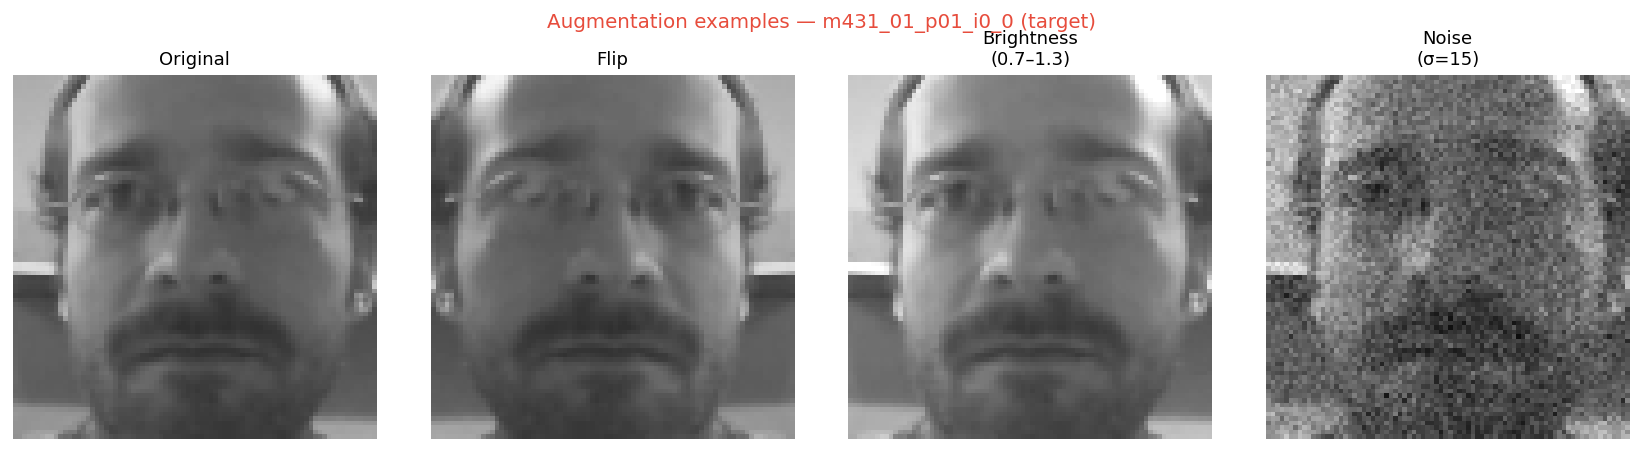

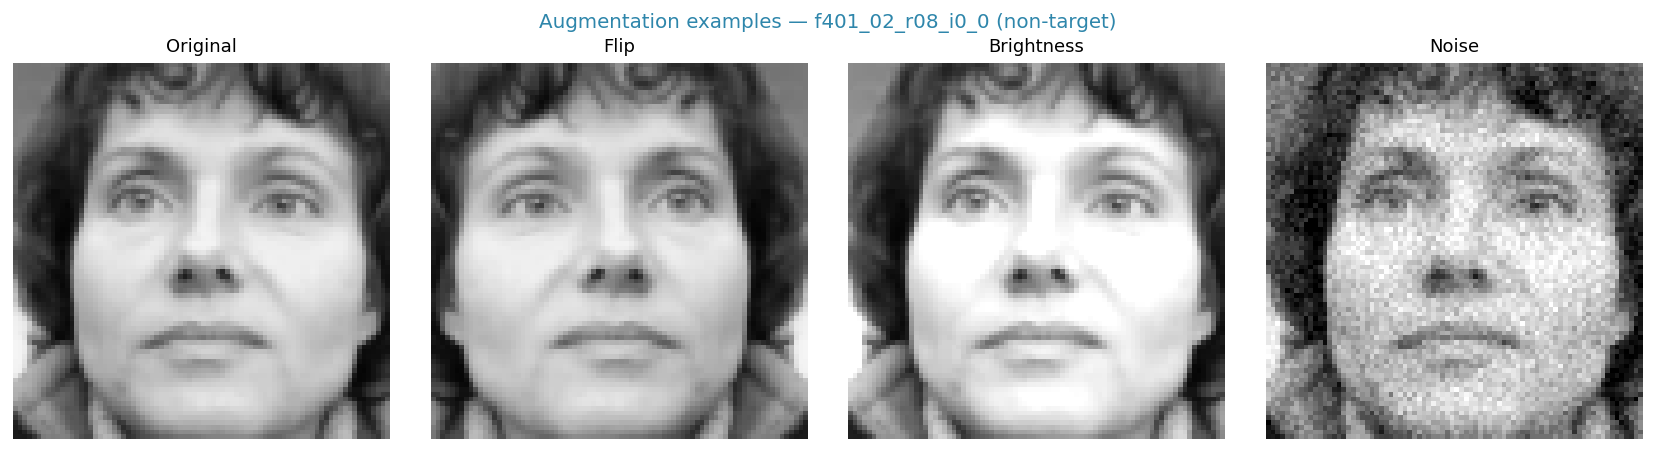

In [3]:
rng_viz = np.random.default_rng(42)
sample_row = manifest[manifest.label == 1].iloc[0]
orig = load_image(find_png(sample_row["stem"], DATA))

augmented = {
    "Original":   orig,
    "Flip":       aug_flip(orig),
    "Brightness\n(0.7–1.3)": aug_brightness(orig, rng_viz),
    "Noise\n(σ=15)": aug_noise(orig, rng_viz),
}

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, (title, img) in zip(axes, augmented.items()):
    ax.imshow(img.reshape(80, 80), cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.suptitle(f"Augmentation examples — {sample_row['stem']} (target)",
             color=COLORS["target"], fontsize=11)
plt.tight_layout()
plt.show()

# Also show for a non-target
sample_nt = manifest[manifest.label == 0].iloc[3]
orig_nt = load_image(find_png(sample_nt["stem"], DATA))
rng_viz2 = np.random.default_rng(42)

augmented_nt = {
    "Original":   orig_nt,
    "Flip":       aug_flip(orig_nt),
    "Brightness": aug_brightness(orig_nt, rng_viz2),
    "Noise":      aug_noise(orig_nt, rng_viz2),
}

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, (title, img) in zip(axes, augmented_nt.items()):
    ax.imshow(img.reshape(80, 80), cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.suptitle(f"Augmentation examples — {sample_nt['stem']} (non-target)",
             color=COLORS["nontarget"], fontsize=11)
plt.tight_layout()
plt.show()

## 3. Cross-validation across all configs

Each config runs the full LOSO CV. The `augment_dataset` function is called
**inside the fold loop, after train/val split** — so val is never touched.

In [4]:
N_PCA = 50
C_LOGREG = 1.0

CONFIGS = {
    "baseline":   "Baseline",
    "flip":       "+Flip",
    "brightness": "+Brightness",
    "noise":      "+Noise",
    "all":        "+All",
}

all_results = {}   # config → list of fold dicts
all_oof     = {}   # config → oof_scores array

for config_key, config_name in CONFIGS.items():
    print(f"\n{'='*50}")
    print(f"Config: {config_name}")
    print('='*50)

    oof_scores   = np.full(len(manifest), np.nan)
    fold_results = []

    for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
        train_df = manifest.loc[train_idx]
        val_df   = manifest.loc[val_idx]
        y_train  = train_df["label"].to_numpy()
        y_val    = val_df["label"].to_numpy()

        # Load original images
        X_train_orig = load_images(train_df, DATA)
        X_val        = load_images(val_df,   DATA)   # val: originals only, always

        # Augment train fold only
        X_train, y_train_aug = augment_dataset(X_train_orig, y_train, config_key, seed=SEED+fold_id)

        # PCA fitted on augmented train
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_val_s   = scaler.transform(X_val)

        pca = PCA(n_components=N_PCA, random_state=SEED)
        X_train_pca = pca.fit_transform(X_train_s)
        X_val_pca   = pca.transform(X_val_s)

        clf = LogisticRegression(C=C_LOGREG, max_iter=1000, random_state=SEED)
        clf.fit(X_train_pca, y_train_aug)

        val_scores = clf.decision_function(X_val_pca)
        oof_scores[val_idx] = val_scores

        eer, _     = compute_eer(val_scores[y_val==1], val_scores[y_val==0])
        min_dcf, _ = compute_min_dcf(val_scores[y_val==1], val_scores[y_val==0])
        fold_results.append({"fold": fold_id, "eer": eer, "min_dcf": min_dcf,
                              "n_train": len(X_train)})
        print(f"  Fold {fold_id}: train={len(X_train)} (aug), val={len(X_val)} → "
              f"EER={eer*100:.2f}%, min-DCF={min_dcf:.4f}")

    all_results[config_name] = fold_results
    all_oof[config_name]     = oof_scores.copy()

print("\nAll configs done.")


Config: Baseline
  Fold 0: train=140 (aug), val=82 → EER=3.47%, min-DCF=0.0694
  Fold 1: train=152 (aug), val=70 → EER=0.83%, min-DCF=0.0167
  Fold 2: train=152 (aug), val=70 → EER=9.17%, min-DCF=0.0833

Config: +Flip
  Fold 0: train=280 (aug), val=82 → EER=3.47%, min-DCF=0.0694
  Fold 1: train=304 (aug), val=70 → EER=9.17%, min-DCF=0.0833
  Fold 2: train=304 (aug), val=70 → EER=0.83%, min-DCF=0.0167

Config: +Brightness
  Fold 0: train=280 (aug), val=82 → EER=2.08%, min-DCF=0.0417
  Fold 1: train=304 (aug), val=70 → EER=0.83%, min-DCF=0.0167
  Fold 2: train=304 (aug), val=70 → EER=1.67%, min-DCF=0.0333

Config: +Noise
  Fold 0: train=280 (aug), val=82 → EER=9.17%, min-DCF=0.0833
  Fold 1: train=304 (aug), val=70 → EER=0.83%, min-DCF=0.0167
  Fold 2: train=304 (aug), val=70 → EER=9.17%, min-DCF=0.0833

Config: +All
  Fold 0: train=560 (aug), val=82 → EER=2.08%, min-DCF=0.0417
  Fold 1: train=608 (aug), val=70 → EER=0.83%, min-DCF=0.0167
  Fold 2: train=608 (aug), val=70 → EER=0.00%, m

## 4. Results — ablation table

In [5]:
print(f"{'Config':<14} {'F0 EER':>8} {'F1 EER':>8} {'F2 EER':>8} {'Mean':>8} {'Std':>8} {'min-DCF':>9}")
print("-" * 68)

summary = []
for config_name, fold_results in all_results.items():
    eers   = [r["eer"]*100  for r in fold_results]
    dcfs   = [r["min_dcf"] for r in fold_results]
    mean_e = np.mean(eers)
    std_e  = np.std(eers)
    mean_d = np.mean(dcfs)
    print(f"{config_name:<14} {eers[0]:>8.2f} {eers[1]:>8.2f} {eers[2]:>8.2f} "
          f"{mean_e:>8.2f} {std_e:>8.2f} {mean_d:>9.4f}")
    summary.append({"config": config_name, "f0": eers[0], "f1": eers[1], "f2": eers[2],
                    "mean": mean_e, "std": std_e, "min_dcf": mean_d})

print("-" * 68)
best = min(summary, key=lambda x: x["mean"])
print(f"Best config: {best['config']}  EER={best['mean']:.2f}±{best['std']:.2f}%")

# OOF overall for best config
oof_best = all_oof[best["config"]]
eer_oof, _   = compute_eer(oof_best[y_all==1], oof_best[y_all==0])
dcf_oof, thr = compute_min_dcf(oof_best[y_all==1], oof_best[y_all==0])
print(f"Best OOF overall: EER={eer_oof*100:.2f}%, min-DCF={dcf_oof:.4f}, threshold={thr:.3f}")

Config           F0 EER   F1 EER   F2 EER     Mean      Std   min-DCF
--------------------------------------------------------------------
Baseline           3.47     0.83     9.17     4.49     3.48    0.0565
+Flip              3.47     9.17     0.83     4.49     3.48    0.0565
+Brightness        2.08     0.83     1.67     1.53     0.52    0.0306
+Noise             9.17     0.83     9.17     6.39     3.93    0.0611
+All               2.08     0.83     0.00     0.97     0.86    0.0194
--------------------------------------------------------------------
Best config: +All  EER=0.97±0.86%
Best OOF overall: EER=4.01%, min-DCF=0.0729, threshold=-5.028


## 5. Visualizations

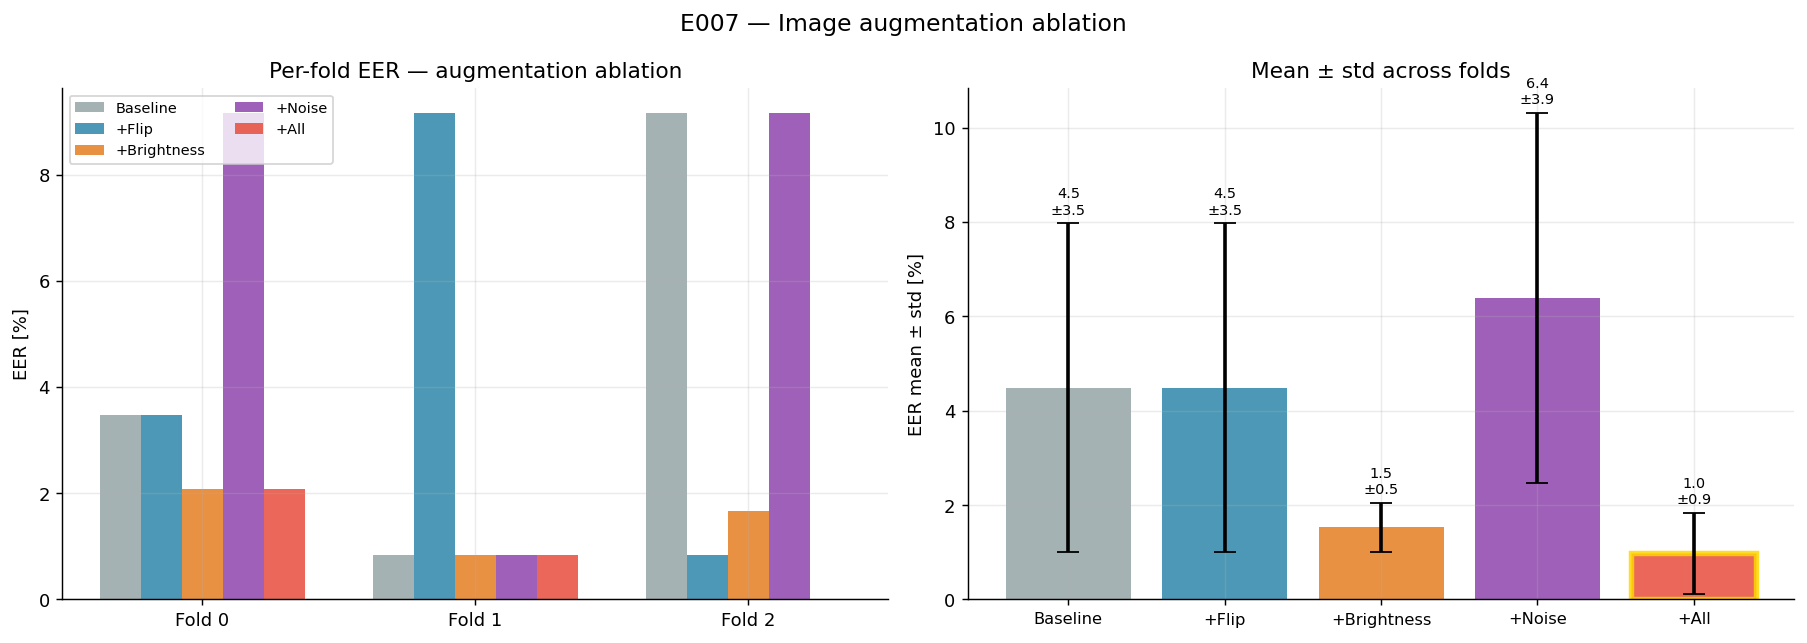

In [6]:
# Ablation bar chart — per fold + mean±std
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = list(all_results.keys())
n_configs = len(configs)
x = np.arange(3)  # 3 folds
width = 0.15

ax = axes[0]
for i, (config_name, fold_results) in enumerate(all_results.items()):
    eers = [r["eer"]*100 for r in fold_results]
    offset = (i - n_configs/2 + 0.5) * width
    bars = ax.bar(x + offset, eers, width,
                  label=config_name, color=CONFIG_COLORS[config_name], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(["Fold 0", "Fold 1", "Fold 2"])
ax.set_ylabel("EER [%]")
ax.set_title("Per-fold EER — augmentation ablation")
ax.legend(fontsize=8, ncol=2)

# Mean ± std
ax = axes[1]
means = [np.mean([r["eer"]*100 for r in fr]) for fr in all_results.values()]
stds  = [np.std( [r["eer"]*100 for r in fr]) for fr in all_results.values()]
colors_list = [CONFIG_COLORS[c] for c in configs]

bars = ax.bar(range(n_configs), means, color=colors_list, alpha=0.85,
              yerr=stds, capsize=6, error_kw=dict(elinewidth=2))
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.2,
            f"{m:.1f}\n±{s:.1f}", ha="center", fontsize=8)

ax.set_xticks(range(n_configs))
ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel("EER mean ± std [%]")
ax.set_title("Mean ± std across folds")

# Highlight winner
best_idx = np.argmin(means)
bars[best_idx].set_edgecolor("gold")
bars[best_idx].set_linewidth(3)
ax.annotate("★ best", xy=(best_idx, means[best_idx] - stds[best_idx] - 0.5),
            ha="center", fontsize=9, color="goldenrod", fontweight="bold")

plt.suptitle("E007 — Image augmentation ablation", fontsize=13)
plt.tight_layout()
plt.show()

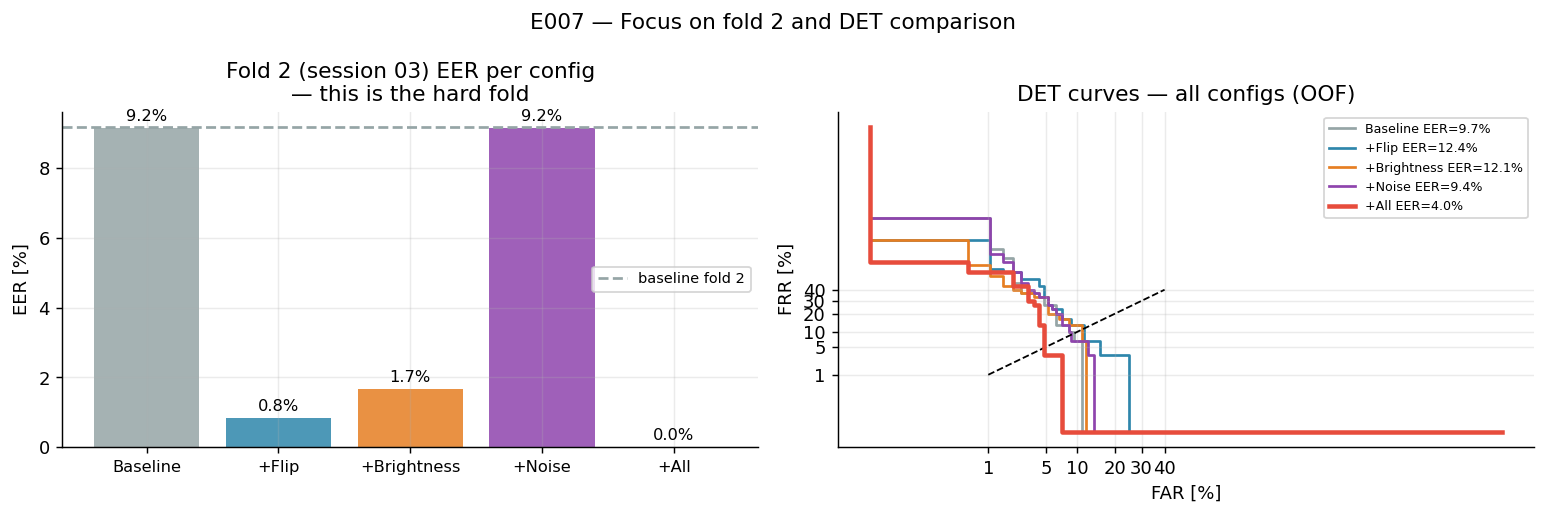

In [7]:
# Fold 2 is the problem fold — zoom in
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
f2_eers = {c: [r["eer"]*100 for r in fr][2]
           for c, fr in all_results.items()}
bars = ax.bar(range(n_configs), f2_eers.values(),
              color=[CONFIG_COLORS[c] for c in f2_eers],
              alpha=0.85)
for bar, val in zip(bars, f2_eers.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2,
            f"{val:.1f}%", ha="center", fontsize=9)
ax.set_xticks(range(n_configs))
ax.set_xticklabels(f2_eers.keys(), fontsize=9)
ax.set_ylabel("EER [%]")
ax.set_title("Fold 2 (session 03) EER per config\n— this is the hard fold")
ax.axhline(9.17, color=COLORS["gray"], ls="--", lw=1.5, label="baseline fold 2")
ax.legend(fontsize=8)

# DET curves for all configs (OOF)
ax = axes[1]
ticks = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
tick_pos = [scipy_norm.ppf(t) for t in ticks]
tick_labels = [f"{int(t*100)}" for t in ticks]

for config_name, oof_s in all_oof.items():
    valid = ~np.isnan(oof_s)
    fpr, tpr, _ = roc_curve(y_all[valid], oof_s[valid])
    far_c = np.clip(fpr, 1e-4, 1-1e-4)
    frr_c = np.clip(1-tpr, 1e-4, 1-1e-4)
    eer_c, _ = compute_eer(oof_s[valid & (y_all==1)], oof_s[valid & (y_all==0)])
    lw = 2.5 if config_name == best["config"] else 1.5
    ax.plot(scipy_norm.ppf(far_c), scipy_norm.ppf(frr_c),
            color=CONFIG_COLORS[config_name], lw=lw,
            label=f"{config_name} EER={eer_c*100:.1f}%",
            zorder=5 if config_name == best["config"] else 1)

ax.plot(tick_pos, tick_pos, "k--", lw=1)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels)
ax.set_xlabel("FAR [%]")
ax.set_ylabel("FRR [%]")
ax.set_title("DET curves — all configs (OOF)")
ax.legend(fontsize=7)

plt.suptitle("E007 — Focus on fold 2 and DET comparison", fontsize=12)
plt.tight_layout()
plt.show()

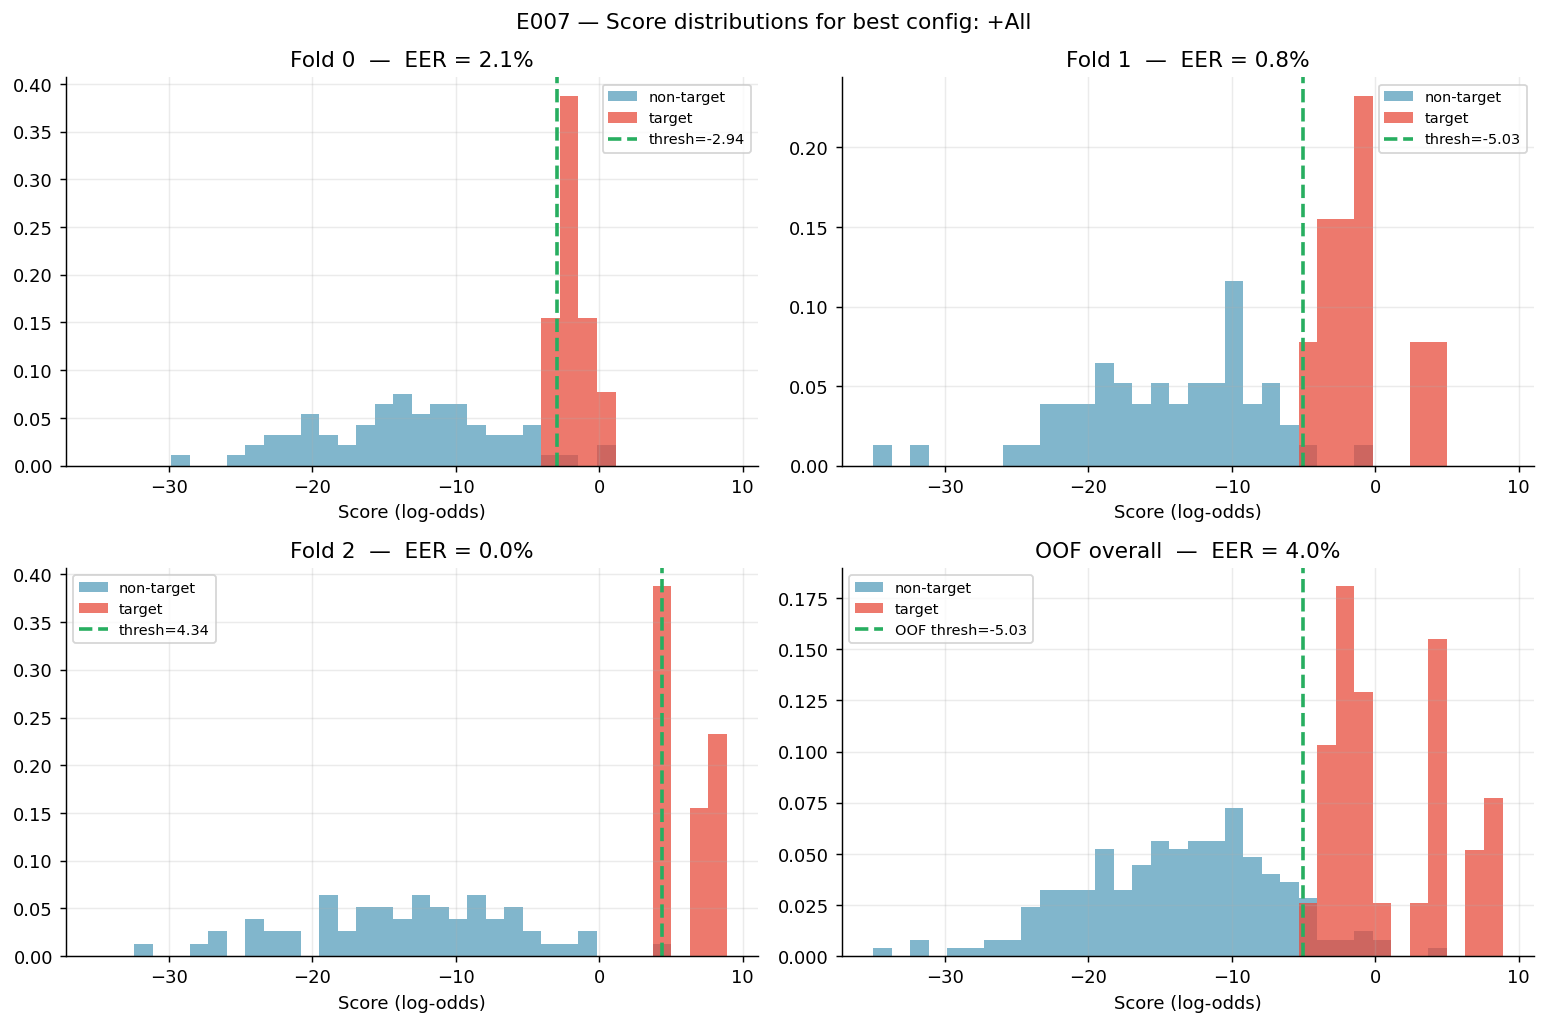

Best config: +All
OOF EER: 4.01%, min-DCF: 0.0729, threshold: -5.028


In [8]:
# Score distributions for the best config
best_name  = best["config"]
oof_best   = all_oof[best_name]
best_folds = all_results[best_name]

# Re-run CV to collect per-fold scores for the best config
best_key = [k for k, v in CONFIGS.items() if v == best_name][0]
fold_scores_best = []
for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    val_scores = oof_best[val_idx]
    val_labels = manifest.loc[val_idx, "label"].to_numpy()
    fold_scores_best.append({"scores": val_scores, "labels": val_labels})

eer_oof, _   = compute_eer(oof_best[y_all==1], oof_best[y_all==0])
dcf_oof, thr = compute_min_dcf(oof_best[y_all==1], oof_best[y_all==0])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
bin_edges = np.linspace(np.nanmin(oof_best), np.nanmax(oof_best), 35)

for i, (ax, fdata) in enumerate(zip(axes[:3], fold_scores_best)):
    s, l = fdata["scores"], fdata["labels"]
    eer_f, thr_f = compute_eer(s[l==1], s[l==0])
    ax.hist(s[l==0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"], label="non-target", density=True)
    ax.hist(s[l==1], bins=bin_edges, alpha=0.75, color=COLORS["target"], label="target", density=True)
    ax.axvline(thr_f, color=COLORS["green"], ls="--", lw=2, label=f"thresh={thr_f:.2f}")
    ax.set_title(f"Fold {i}  —  EER = {eer_f*100:.1f}%")
    ax.set_xlabel("Score (log-odds)")
    ax.legend(fontsize=8)

ax = axes[3]
ax.hist(oof_best[y_all==0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"], label="non-target", density=True)
ax.hist(oof_best[y_all==1], bins=bin_edges, alpha=0.75, color=COLORS["target"], label="target", density=True)
ax.axvline(thr, color=COLORS["green"], ls="--", lw=2, label=f"OOF thresh={thr:.2f}")
ax.set_title(f"OOF overall  —  EER = {eer_oof*100:.1f}%")
ax.set_xlabel("Score (log-odds)")
ax.legend(fontsize=8)

plt.suptitle(f"E007 — Score distributions for best config: {best_name}", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Best config: {best_name}")
print(f"OOF EER: {eer_oof*100:.2f}%, min-DCF: {dcf_oof:.4f}, threshold: {thr:.3f}")